# Классификация: SI выше медианы

В данном ноутбуке решается задача бинарной классификации.

Цель - предсказать, превышает ли значение SI медианное значение выборки.

Параметр SI является расчетным показателем и связан с соотношением CC50 и IC50. Более высокий SI означает более выгодное сочетание эффективности и токсичности соединения.

Так как SI рассчитывается на основе IC50 и CC50, эти параметры не используются в качестве признаков при обучении модели, чтобы избежать утечки данных.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import HistGradientBoostingClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay
from sklearn.inspection import permutation_importance

# Загрузка данных

Загружаем исходный датасет и удаляем технические столбцы.

In [2]:
df = pd.read_excel("../data/compounds.xlsx")

df = df.drop(
    columns=[col for col in df.columns if "Unnamed" in col],
    errors="ignore"
)

df.head()

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,...,0,0,0,0,0,0,0,0,3,0
1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,...,0,0,0,0,0,0,0,0,3,0
2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,...,0,0,0,0,0,0,0,0,3,0
3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,...,0,0,0,0,0,0,0,0,4,0
4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,...,0,0,0,0,0,0,0,0,0,0


In [3]:
df.shape

(1001, 213)

# Создание целевой переменной

Для классификации используется бинарный признак: превышает ли SI медианное значение.

Так как порогом является медиана, классы должны получиться примерно сбалансированными.

In [4]:
target = "SI"

median_value = df[target].median()

y = (df[target] > median_value).astype(int)

median_value

np.float64(3.846153846153846)

In [5]:
y.value_counts(normalize=True)

SI
0    0.5005
1    0.4995
Name: proportion, dtype: float64

Классы получились примерно сбалансированными, так как порог выбран по медиане. Это позволяет использовать accuracy вместе с precision, recall, F1 и ROC-AUC.

# Подготовка признаков

Из признакового пространства исключаются IC50, CC50 и SI.

SI является целевой переменной, а IC50 и CC50 используются для его расчета. Поэтому использование этих признаков привело бы к утечке данных.

В качестве признаков используются только числовые характеристики химических соединений.

In [6]:
X = df.drop(
    columns=["IC50, mM", "CC50, mM", "SI"],
    errors="ignore"
)

X = X.select_dtypes(include=["number"])

X.shape

(1001, 210)

# Разделение данных

Данные разделяются на обучающую и тестовую выборки.

Используется stratify, чтобы сохранить баланс классов в train и test.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Метрики качества

Для оценки моделей используются accuracy, precision, recall, F1 и ROC-AUC.

Так как классы по медиане примерно сбалансированы, accuracy является полезной метрикой. Однако для более полной оценки также используются F1 и ROC-AUC.

In [8]:
def classification_metrics(y_true, y_pred, y_proba):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_proba)
    }

# Baseline модель

В качестве baseline используется DummyClassifier, который предсказывает наиболее частый класс.

Это позволяет проверить, действительно ли ML-модели находят полезные закономерности в данных.

In [9]:
dummy = DummyClassifier(strategy="most_frequent")

dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)

baseline_metrics = {
    "accuracy": accuracy_score(y_test, y_pred_dummy),
    "precision": precision_score(y_test, y_pred_dummy, zero_division=0),
    "recall": recall_score(y_test, y_pred_dummy, zero_division=0),
    "f1": f1_score(y_test, y_pred_dummy, zero_division=0),
    "roc_auc": 0.5,
    "model": "DummyClassifier"
}

baseline_metrics

{'accuracy': 0.5024875621890548,
 'precision': 0.0,
 'recall': 0.0,
 'f1': 0.0,
 'roc_auc': 0.5,
 'model': 'DummyClassifier'}

# Сравнение моделей

Для решения задачи сравним несколько типов моделей:

- логистическую регрессию
- метод ближайших соседей
- решающее дерево
- ансамбли деревьев
- бустинговые модели

Это позволит понять, какие алгоритмы лучше подходят для разделения соединений по уровню SI.

In [10]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=5000, random_state=42),
    "KNN": KNeighborsClassifier(),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42),
    "ExtraTrees": ExtraTreesClassifier(random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=42)
}

In [11]:
results = []

for name, model in models.items():

    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("variance", VarianceThreshold()),
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    if hasattr(pipe.named_steps["model"], "predict_proba"):
        y_proba = pipe.predict_proba(X_test)[:, 1]
    else:
        y_proba = y_pred

    metrics = classification_metrics(y_test, y_pred, y_proba)
    metrics["model"] = name
    results.append(metrics)

results_df = pd.DataFrame(results)

results_df = results_df.sort_values("f1",ascending=False)

results_df

,accuracy,precision,recall,f1,roc_auc,model
1,0.651741,0.641509,0.68,0.660194,0.706832,KNN
4,0.656716,0.670330,0.61,0.638743,0.641980,ExtraTrees
6,0.636816,0.639175,0.62,0.629442,0.671535,HistGradientBoosting
0,0.621891,0.615385,0.64,0.627451,0.655792,LogisticRegression
3,0.646766,0.674699,0.56,0.612022,0.675198,RandomForest
5,0.606965,0.612903,0.57,0.590674,0.672376,GradientBoosting
2,0.582090,0.580000,0.58,0.580000,0.581485,DecisionTree


# Визуальное сравнение моделей

Для более наглядного сравнения построим графики по основным метрикам.

Для accuracy, F1 и ROC-AUC большее значение означает лучшее качество модели.

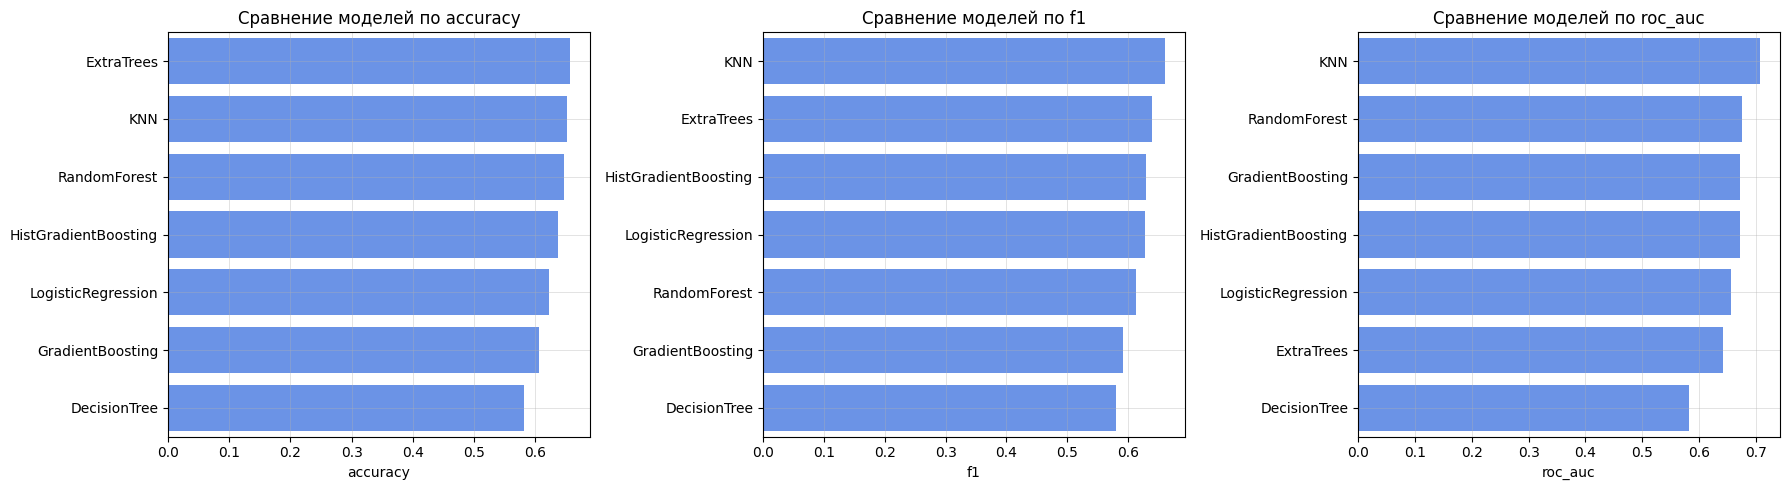

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_names = ["accuracy", "f1", "roc_auc"]

for i, metric in enumerate(metrics_names):

    sns.barplot(
        data=results_df.sort_values(
            metric,
            ascending=False
        ),
        x=metric,
        y="model",
        ax=axes[i]
    )

    axes[i].set_title(f"Сравнение моделей по {metric}")
    axes[i].set_ylabel("")
    axes[i].grid()

plt.tight_layout()
plt.show()

Сравнение моделей показало, что задача классификации SI относительно медианы решается сложнее, чем аналогичные задачи для IC50 и CC50.

Наилучший результат по F1 показала модель KNN. Также относительно близкое качество получили ExtraTreesClassifier и HistGradientBoostingClassifier.

Качество выше baseline, значит химические признаки содержат полезную информацию для разделения соединений по SI. Однако значения F1 и ROC-AUC ниже, чем в задачах классификации IC50 и CC50.

Это может быть связано с тем, что SI является производной величиной от IC50 и CC50. При этом IC50 и CC50 были исключены из признаков, чтобы избежать утечки данных, поэтому задача стала более сложной.

# Подбор гиперпараметров

После первичного сравнения моделей видно, что задача классификации `SI > median` решается сложнее, чем аналогичные задачи для IC50 и CC50.

Лучший результат на первом этапе показала модель KNN, однако ансамблевые модели тоже дали близкое качество. Поэтому для подбора гиперпараметров были выбраны несколько разных подходов:

- KNN как лучшая модель по F1 на первичном сравнении;
- ExtraTrees как сильная ансамблевая модель на деревьях;
- HistGradientBoosting как бустинговая модель, хорошо показавшая себя в предыдущих задачах.

В качестве основной метрики для GridSearch используется F1. Эта метрика выбрана потому, что она учитывает баланс между precision и recall и хорошо подходит для бинарной классификации.

Цель данного этапа - проверить, можно ли улучшить качество моделей за счет настройки гиперпараметров, а также понять, сохраняется ли преимущество KNN после более честного сравнения на кросс-валидации.

In [13]:
param_grids = {
    "KNN": {
        "model": KNeighborsClassifier(),
        "params": {
            "model__n_neighbors": [3, 5, 7, 9, 11, 15],
            "model__weights": ["uniform", "distance"],
            "model__p": [1, 2]
        }
    },

    "ExtraTrees": {
        "model": ExtraTreesClassifier(random_state=42),
        "params": {
            "model__n_estimators": [100, 200, 300],
            "model__max_depth": [5, 10, None],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4]
        }
    },

    "HistGradientBoosting": {
        "model": HistGradientBoostingClassifier(random_state=42),
        "params": {
            "model__max_iter": [100, 200, 300],
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__max_leaf_nodes": [15, 31, 63],
            "model__l2_regularization": [0.0, 0.1, 1.0]
        }
    }
}

In [14]:
selected_models = [
    "KNN",
    "ExtraTrees",
    "HistGradientBoosting"
]

grid_results = []

best_model = None
best_score = -np.inf
best_model_name = None

for name in selected_models:

    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("variance", VarianceThreshold()),
        ("scaler", StandardScaler()),
        ("model", param_grids[name]["model"])
    ])

    grid = GridSearchCV(
        pipe,
        param_grids[name]["params"],
        cv=5,
        scoring="f1",
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    grid_results.append({
        "model": name,
        "best_f1_cv": grid.best_score_,
        "best_params": grid.best_params_
    })

    if grid.best_score_ > best_score:
        best_score = grid.best_score_
        best_model = grid.best_estimator_
        best_model_name = name

grid_results_df = pd.DataFrame(grid_results)

grid_results_df = grid_results_df.sort_values(
    "best_f1_cv",
    ascending=False
)

grid_results_df

,model,best_f1_cv,best_params
0,KNN,0.682334,"{'model__n_neighbors': 3, 'model__p': 1, 'mode..."
2,HistGradientBoosting,0.669178,"{'model__l2_regularization': 0.0, 'model__lear..."
1,ExtraTrees,0.668937,"{'model__max_depth': 10, 'model__min_samples_l..."


По результатам GridSearchCV лучшей моделью стала KNN.

Лучшие параметры модели:

- n_neighbors = 3
- p = 1
- weights = uniform

ExtraTrees и HistGradientBoosting показали близкое качество на кросс-валидации, но по F1 уступили KNN. Поэтому для дальнейшей оценки была выбрана настроенная модель KNN.

In [15]:
best_model_name

'KNN'

In [16]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

best_metrics = classification_metrics(
    y_test,
    y_pred,
    y_proba
)

best_metrics

{'accuracy': 0.6716417910447762,
 'precision': 0.6666666666666666,
 'recall': 0.68,
 'f1': 0.6732673267326733,
 'roc_auc': 0.6856930693069307}

In [17]:
before_tuning = results_df[
    results_df["model"] == best_model_name
].copy()

before_tuning["stage"] = "До подбора"

after_tuning = pd.DataFrame([best_metrics])
after_tuning["model"] = best_model_name
after_tuning["stage"] = "После подбора"

compare_tuning = pd.concat(
    [before_tuning, after_tuning],
    ignore_index=True
)

compare_tuning[
    ["stage", "model", "accuracy", "precision", "recall", "f1", "roc_auc"]
]

,stage,model,accuracy,precision,recall,f1,roc_auc
0,До подбора,KNN,0.651741,0.641509,0.68,0.660194,0.706832
1,После подбора,KNN,0.671642,0.666667,0.68,0.673267,0.685693


Сравнение KNN до и после подбора гиперпараметров показало, что настройка модели дала небольшой прирост качества по основной метрике F1.

После подбора accuracy выросла с 0.652 до 0.672, precision вырос с 0.642 до 0.667, а F1 вырос с 0.660 до 0.673. Recall остался на том же уровне 0.68.

При этом ROC-AUC немного снизился с 0.707 до 0.686. Это означает, что модель стала немного лучше по выбранному порогу классификации, но хуже ранжирует объекты по вероятности положительного класса.

Так как в GridSearch основной метрикой был выбран F1, в качестве финальной модели оставляем настроенную KNN. Однако важно отметить, что качество модели для SI остается ниже, чем для задач классификации IC50 и CC50.

In [18]:
final_model_name = best_model_name
final_model = best_model

y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

final_metrics = classification_metrics(
    y_test,
    y_pred,
    y_proba
)

final_metrics

{'accuracy': 0.6716417910447762,
 'precision': 0.6666666666666666,
 'recall': 0.68,
 'f1': 0.6732673267326733,
 'roc_auc': 0.6856930693069307}

# Матрица ошибок

Матрица ошибок показывает, сколько объектов каждого класса модель классифицировала правильно и неправильно.

Класс 0 соответствует объектам с SI <= median.
Класс 1 соответствует объектам с SI > median.

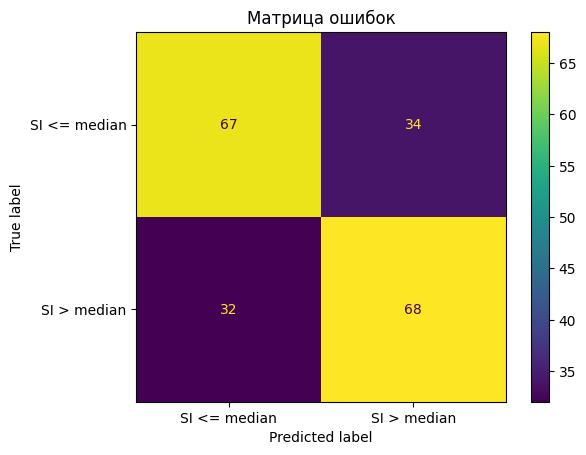

In [19]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["SI <= median", "SI > median"]
)

disp.plot()

plt.title("Матрица ошибок")
plt.show()

In [20]:
tn, fp, fn, tp = cm.ravel()

print("True Negative:", tn)
print("False Positive:", fp)
print("False Negative:", fn)
print("True Positive:", tp)

True Negative: 67
False Positive: 34
False Negative: 32
True Positive: 68


# ROC-кривая

ROC-кривая показывает способность модели разделять два класса при разных порогах классификации.

Чем выше ROC-кривая расположена над диагональю случайного классификатора, тем лучше модель различает классы.

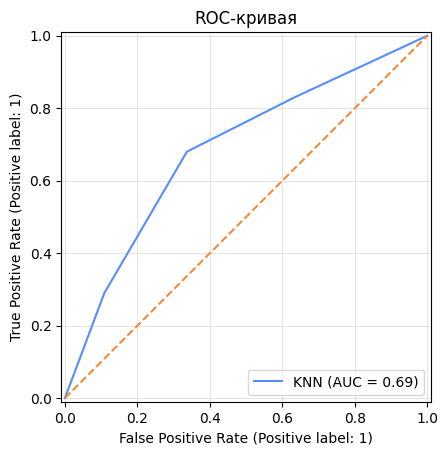

In [21]:
RocCurveDisplay.from_estimator(
    final_model,
    X_test,
    y_test,
    name=final_model_name
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title("ROC-кривая")
plt.grid()
plt.show()

ROC-кривая показывает, что финальная модель KNN отделяет соединения с SI выше медианы от остальных лучше случайного классификатора.

Значение ROC-AUC составляет около 0.69. Это выше случайного уровня 0.5, однако ниже результатов, полученных для задач классификации IC50 и CC50.

Такой результат подтверждает, что задача классификации SI относительно медианы сложнее. Это связано с тем, что SI является расчетной величиной на основе IC50 и CC50, но сами IC50 и CC50 были исключены из признаков для предотвращения утечки данных.

Также ROC-кривая имеет ступенчатый вид, потому что финальная модель KNN использует небольшое число соседей. При n_neighbors = 3 модель выдаёт ограниченное число возможных вероятностей класса.

# Анализ важности признаков

Так как финальная модель KNN не имеет встроенной оценки важности признаков, используется permutation importance.

Метод показывает, насколько ухудшается качество модели, если значения отдельного признака случайно перемешать.

Чем сильнее падает качество, тем важнее признак для модели.

In [22]:
perm_importance = permutation_importance(
    final_model,
    X_test,
    y_test,
    scoring="f1",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

In [23]:
importances = pd.DataFrame({
    "feature": X.columns,
    "importance": perm_importance.importances_mean
})

importances = importances.sort_values(
    "importance",
    ascending=False
).head(15)

importances

,feature,importance
23,BCUT2D_LOGPLOW,-0.007183
196,fr_priamide,-0.007183
202,fr_sulfone,-0.009994
49,PEOE_VSA11,-0.011639
4,qed,-0.011912
60,PEOE_VSA9,-0.012307
44,Kappa2,-0.012612
86,EState_VSA11,-0.012723
76,SlogP_VSA3,-0.012913
20,BCUT2D_CHGHI,-0.012988


Permutation importance для финальной модели KNN не выявил устойчивых положительных вкладов отдельных признаков.

Все значения importance оказались около нуля или отрицательными. Это означает, что случайное перемешивание отдельных признаков не ухудшало F1 на тестовой выборке.

Такой результат может быть связан с несколькими причинами: модель KNN опирается на расстояния между объектами и комбинации признаков, многие химические дескрипторы коррелируют между собой, а сама задача SI > median оказалась достаточно сложной и нестабильной.

Поэтому для данной модели нельзя выделить отдельные признаки как надежно наиболее важные. Более корректный вывод: модель использует общую структуру признакового пространства, но вклад отдельных дескрипторов по permutation importance выражен слабо.

# Выводы

В рамках задачи была построена модель бинарной классификации для определения того, превышает ли значение SI медианное значение выборки.

Показатель SI является расчетной величиной и связан с отношением CC50 к IC50. Поэтому при построении модели из признаков были исключены IC50, CC50 и сам SI, чтобы избежать утечки данных.

Целевая переменная была сформирована на основе медианы SI, поэтому классы получились примерно сбалансированными. Для оценки качества использовались accuracy, precision, recall, F1 и ROC-AUC.

Baseline-модель DummyClassifier показала качество около случайного уровня. Основные ML-модели смогли превзойти baseline, однако качество оказалось ниже, чем в задачах классификации IC50 и CC50 относительно медианы.

На первичном сравнении лучший результат показала модель KNN. После подбора гиперпараметров она также осталась лучшей моделью по F1. Финальная модель использует 3 ближайших соседа, манхэттенское расстояние и равные веса соседей.

После подбора гиперпараметров качество KNN немного улучшилось по F1: значение F1 выросло примерно с 0.66 до 0.67. Accuracy также немного увеличилась. При этом ROC-AUC немного снизился, что говорит о том, что модель стала лучше работать при выбранном пороге классификации, но хуже ранжировать объекты по вероятности положительного класса.

ROC-AUC финальной модели составил около 0.69. Это выше случайного уровня 0.5, но заметно ниже результатов, полученных для IC50 и CC50. Поэтому качество модели можно считать умеренным.

Такой результат логичен: SI является производной величиной от IC50 и CC50, но сами IC50 и CC50 не использовались как признаки. Модель пытается восстановить информацию о SI только по химическим дескрипторам, поэтому задача получается сложнее.

Проверка permutation importance не выявила признаков с устойчивым положительным вкладом. Это означает, что модель KNN не опирается на один или несколько явно доминирующих признаков, а использует общую структуру признакового пространства.

Таким образом, задача классификации SI относительно медианы решается хуже, чем аналогичные задачи для IC50 и CC50. Тем не менее модель KNN показывает качество выше baseline и может использоваться как базовое решение для разделения соединений по SI относительно медианного значения.